In [1]:
import os
from google.colab import drive

# Démonter et remonter proprement
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [2]:
!pip install segmentation-models-pytorch albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00


🚀 Device : cuda
GPU : Tesla T4

📊 Dataset
Train : 1616
Val   : 346
Test  : 347

🔄 Chargement U-Net...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✅ U-Net prêt

🚀 Début entraînement U-Net

Epoch [1/30] Train Loss: 1.0627 Val Loss: 0.9830 Val IoU: 0.1870
💾 Meilleur modèle sauvegardé : IoU=0.1870
Epoch [2/30] Train Loss: 0.9653 Val Loss: 0.9371 Val IoU: 0.2000
💾 Meilleur modèle sauvegardé : IoU=0.2000
Epoch [3/30] Train Loss: 0.8922 Val Loss: 0.8606 Val IoU: 0.1951
Epoch [4/30] Train Loss: 0.7694 Val Loss: 0.7303 Val IoU: 0.2308
💾 Meilleur modèle sauvegardé : IoU=0.2308
Epoch [5/30] Train Loss: 0.7197 Val Loss: 0.7174 Val IoU: 0.2315
💾 Meilleur modèle sauvegardé : IoU=0.2315
Epoch [6/30] Train Loss: 0.7093 Val Loss: 0.6870 Val IoU: 0.2502
💾 Meilleur modèle sauvegardé : IoU=0.2502
Epoch [7/30] Train Loss: 0.7017 Val Loss: 0.6820 Val IoU: 0.2514
💾 Meilleur modèle sauvegardé : IoU=0.2514
Epoch [8/30] Train Loss: 0.6923 Val Loss: 0.6829 Val IoU: 0.2511
Epoch [9/30] Train Loss: 0.6924 Val Loss: 0.6792 Val IoU: 0.2519
💾 Meilleur modèle sauvegardé : IoU=0.2519
Epoch [10/30] Train Loss: 0.6879 Val Loss: 0.6771 Val IoU: 0.2532
💾 Meilleur mo

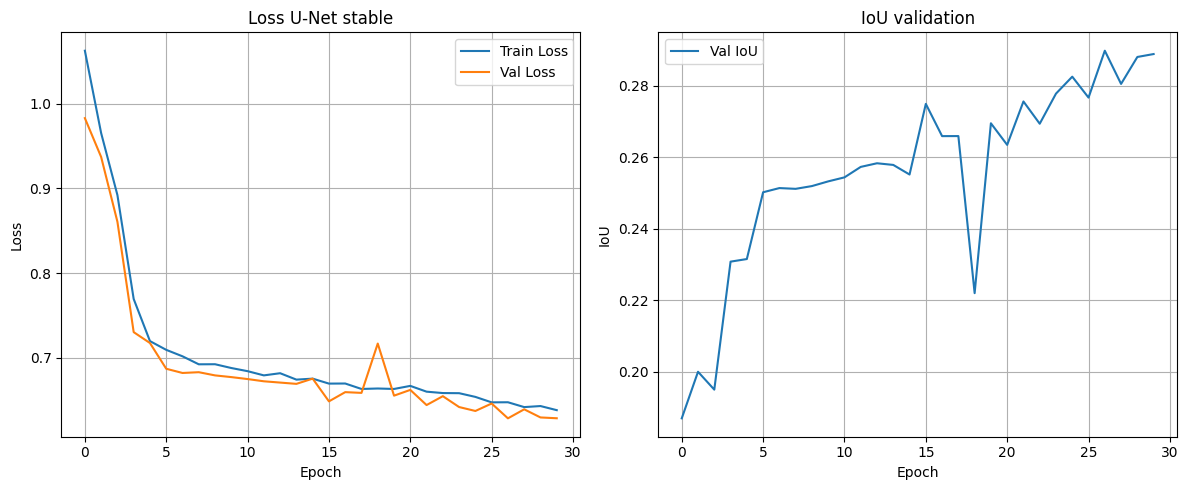


🧪 Test final U-Net stable
✅ Test Loss : 0.5882
✅ Test IoU  : 0.3209

✅ ENTRAÎNEMENT TERMINÉ
💾 Modèle sauvegardé : /content/drive/MyDrive/dislocation_2026/fine_tuning/unet_binary_dislocation_stable_A2.pth
📈 Courbes sauvegardées : /content/drive/MyDrive/dislocation_2026/fine_tuning/courbes_unet_stable_A2.png
🏆 Meilleur IoU validation : 0.2897


In [3]:
# -*- coding: utf-8 -*-
"""
BASE_DIR = "/content/drive/MyDrive/dislocation_2026"

DATASET_DIR = os.path.join(BASE_DIR,"fine_tuning","unet_split")
MODEL_SAVE_PATH = os.path.join(BASE_DIR,"fine_tuning","unet_binary_dislocation_stable_T.pth")
CURVE_SAVE_PATH = os.path.join(BASE_DIR,"fine_tuning","courbes_unet_stable_T.png")


03_train_unet_stable.py

Version stable pour Colab :
- U-Net binaire
- Encoder ResNet34
- CLAHE
- Albumentations simples
- BCE + Dice Loss
"""

import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp

import albumentations as A
from albumentations.pytorch import ToTensorV2


# ============================================================
# CHEMINS COLAB
# ============================================================
BASE_DIR = "/content/drive/MyDrive/dislocation_2026"

DATASET_DIR = os.path.join(BASE_DIR,"fine_tuning","unet_split")
MODEL_SAVE_PATH = os.path.join(BASE_DIR,"fine_tuning","unet_binary_dislocation_stable_A2.pth")
CURVE_SAVE_PATH = os.path.join(BASE_DIR,"fine_tuning","courbes_unet_stable_A2.png")
# ============================================================
# PARAMÈTRES
# ============================================================

BATCH_SIZE = 4
EPOCHS = 30
LR = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("🚀 Device :", DEVICE)
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))


# ============================================================
# AUGMENTATIONS
# ============================================================

train_transform = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),

    A.RandomGamma(gamma_limit=(80, 120), p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.20,
        p=0.5
    ),

    A.GaussianBlur(blur_limit=(3, 5), p=0.3),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=0.5),

    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])


val_transform = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),

    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])


# ============================================================
# DATASET
# ============================================================

class UNetDataset(Dataset):

    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = sorted(
            glob.glob(os.path.join(image_dir, "*.tif"))
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = self.images[idx]
        image_name = os.path.basename(image_path)
        base = image_name.replace(".tif", "")

        mask_path = os.path.join(
            self.mask_dir,
            base + ".png"
        )

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"Image introuvable : {image_path}")

        if mask is None:
            raise ValueError(f"Masque introuvable : {mask_path}")

        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0).float()

        return image, mask


# ============================================================
# LOAD DATA
# ============================================================

train_dataset = UNetDataset(
    os.path.join(DATASET_DIR, "train", "images"),
    os.path.join(DATASET_DIR, "train", "masks"),
    transform=train_transform
)

val_dataset = UNetDataset(
    os.path.join(DATASET_DIR, "val", "images"),
    os.path.join(DATASET_DIR, "val", "masks"),
    transform=val_transform
)

test_dataset = UNetDataset(
    os.path.join(DATASET_DIR, "test", "images"),
    os.path.join(DATASET_DIR, "test", "masks"),
    transform=val_transform
)

print("\n📊 Dataset")
print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ============================================================
# MODEL U-NET
# ============================================================

print("\n🔄 Chargement U-Net...")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None
)

model = model.to(DEVICE)

print("✅ U-Net prêt")


# ============================================================
# LOSS BCE + DICE
# ============================================================

class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (
            (2 * intersection + self.smooth) /
            (probs.sum() + targets.sum() + self.smooth)
        )

        return 1 - dice


dice_loss = smp.losses.DiceLoss(mode="binary")

focal_loss = smp.losses.FocalLoss(mode="binary")

def combined_loss(outputs, masks):

    return (
        dice_loss(outputs, masks)
        + focal_loss(outputs, masks)
    )

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# IOU
# ============================================================

def calculate_iou(outputs, masks, threshold=0.5):

    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()

    intersection = (preds * masks).sum()
    union = preds.sum() + masks.sum() - intersection

    if union == 0:
        return 1.0

    return (intersection / union).item()


# ============================================================
# EVALUATION
# ============================================================

def evaluate(loader):

    model.eval()

    total_loss = 0
    total_iou = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            loss = combined_loss(outputs, masks)
            iou = calculate_iou(outputs, masks)

            total_loss += loss.item()
            total_iou += iou

    return total_loss / len(loader), total_iou / len(loader)


# ============================================================
# TRAIN
# ============================================================

best_iou = 0

train_losses = []
val_losses = []
val_ious = []

print("\n🚀 Début entraînement U-Net\n")

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0

    for images, masks in train_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    val_loss, val_iou = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ious.append(val_iou)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val IoU: {val_iou:.4f}"
    )

    if val_iou > best_iou:

        best_iou = val_iou

        torch.save(
            model.state_dict(),
            MODEL_SAVE_PATH
        )

        print(f"💾 Meilleur modèle sauvegardé : IoU={best_iou:.4f}")


# ============================================================
# COURBES
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss U-Net stable")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_ious, label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("IoU validation")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(CURVE_SAVE_PATH, dpi=120)
plt.show()


# ============================================================
# TEST FINAL
# ============================================================

print("\n🧪 Test final U-Net stable")

model.load_state_dict(
    torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
)

test_loss, test_iou = evaluate(test_loader)

print(f"✅ Test Loss : {test_loss:.4f}")
print(f"✅ Test IoU  : {test_iou:.4f}")

print("\n===================================")
print("✅ ENTRAÎNEMENT TERMINÉ")
print("===================================")
print(f"💾 Modèle sauvegardé : {MODEL_SAVE_PATH}")
print(f"📈 Courbes sauvegardées : {CURVE_SAVE_PATH}")
print(f"🏆 Meilleur IoU validation : {best_iou:.4f}")

In [ ]:
import os, shutil

drive_dir = "/content/drive/MyDrive/dislocation_2026/fine_tuning"
os.makedirs(drive_dir, exist_ok=True)

shutil.copy(
    "/content/unet_split_v2/fine_tuning/unet_binary_dislocation_stable_T2.pth",
    drive_dir
)

shutil.copy(
    "/content/unet_split_v2/fine_tuning/courbes_unet_stable_T2.png",
    drive_dir
)

print("✅ Modèle et courbes copiés dans Drive")

✅ Modèle et courbes copiés dans Drive
